# Notebook 4  - Prompted SAM 2 Refinement (Colab / GPU)

**Stage 4 · runs last · lowest priority  - the only GPU stage.**


> **Pipeline execution order: `1 -> 2 -> 3 -> 4`.**
> 1 occupancy · 2 watershed (room masks) · 3 boundary-ring wall assignment · 4 SAM
> refinement. Stages 1-3 run **locally on CPU**; this stage runs in **Google Colab on a
> GPU**. Copy the `scan2bim/` package and the `scan2bim_out/` stage ZIPs from stages 1-2
> to Google Drive, then run this notebook there.

## Purpose
Refine the watershed room masks with **prompted** SAM 2. SAM is *not* run blindly: it is
prompted once per watershed room (positive points from the room's eroded interior + the
room box), so every mask is labelled by construction. A single-pass region-adjacency graph
then **merges** rooms a confident SAM mask spans and **splits** a room a confident SAM mask
cuts - but only where the geometry is weak (an open distance-transform ridge, never on wall
pixels). The watershed is always the prior, and the wall mask is re-imposed as hard
barriers, so refined masks align **pixel-for-pixel** with the watershed.

## Model abstraction (swap SAM2 -> SAM3 -> SAM1 in one line)
Inference is wrapped behind `scan2bim.MaskGenerator`. `CFG.sam_backend` selects the model
(`'sam2'` default | `'sam3'` | `'sam1'`); the refinement code only calls `set_image` /
`predict`. **With no GPU / checkpoint, this notebook passes the watershed labels through
unchanged - it never fabricates masks.**

## Inputs
- `occupancy.png`, `wallness.npy`, `coverage.npy` from `stage1_occupancy.zip` (the SAM image).
- `room_labels.npy`, `walls.npy`, `footprint.npy`, `config.json` from `stage2_watershed.zip`.
- A SAM 2.1 checkpoint (`CFG.sam_ckpt`) + its Hydra config name (`CFG.sam_model_cfg`).

## Outputs  (`{out_root}/stage4_sam_refined/`, zipped to `stage4_sam_refined.zip`)
- `room_labels_refined.npy` - the final room assignments.
- `room_labels_refined_color.png`, `transform.json`, `config.json`.

## 1 - Mount Google Drive & locate the scan2bim package
Stages 1-2 wrote their ZIPs locally; copy `scan2bim/`, `params.yaml`, and the stage-1/2 ZIPs
to Drive, then point `PROJECT_DIR` at the folder that contains them. This is the **only**
paths cell  - nothing else needs editing. Runs locally too (CPU pass-through).

In [1]:
# ============== scan2bim setup (Colab / GPU)  - the ONLY paths cell ==============
import sys, os
import numpy as np

PROJECT_ROOT = os.path.abspath('../../..')   # adjust dots to match depth
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    # EDIT THIS for your Drive layout (the folder that CONTAINS scan2bim/ and scan2bim_out/).
    PROJECT_DIR = '/content/drive/MyDrive/onestruction'
    if PROJECT_DIR not in sys.path:
        sys.path.insert(0, PROJECT_DIR)
    import scan2bim
else:                                       # local: the editable install resolves it
    import scan2bim
    PROJECT_DIR = scan2bim.project_root()

from scan2bim import artifacts as A, viz
OUT_ROOT = os.path.join(PROJECT_DIR, 'scan2bim_out')
print('scan2bim', scan2bim.__version__, '| in_colab:', IN_COLAB)
print('PROJECT_DIR:', PROJECT_DIR)
print('OUT_ROOT   :', OUT_ROOT)

scan2bim 1.0.0 | in_colab: False
PROJECT_DIR: /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM
OUT_ROOT   : /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM/scan2bim_out


## 2 - Check the GPU, then install SAM 2 + the SAM 2.1 checkpoint
SAM 2 needs a CUDA GPU to be practical. If none is present the refinement still runs as a
watershed pass-through (nothing is fabricated).

In [2]:
# ------------------------------- GPU check -------------------------------
try:
    import torch
    if torch.cuda.is_available():
        print('CUDA OK ->', torch.cuda.get_device_name(0))
    else:
        print('WARNING: no CUDA GPU. In Colab: Runtime > Change runtime type > GPU. '
              'Without a working SAM backend, this notebook passes the watershed labels '
              'through unchanged.')
except Exception as e:
    print('torch not installed yet:', e, '- install it in the next cell, or rely on pass-through.')

torch not installed yet: No module named 'torch' - install it in the next cell, or rely on pass-through.


In [3]:
# ===== Install SAM 2 + download the SAM 2.1 checkpoint (Colab; runs itself, idempotent) =====
# Verified against github.com/facebookresearch/sam2. Needs python>=3.10, torch>=2.5.1,
# torchvision>=0.20.1 (preinstalled on Colab GPU runtimes). No uncommenting ritual: the cell
# installs once if missing and downloads the checkpoint once if absent.
SAM_CKPT = '/content/sam2.1_hiera_large.pt'
SAM_CFG  = 'configs/sam2.1/sam2.1_hiera_l.yaml'
CKPT_URL = 'https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt'

if IN_COLAB:
    import importlib.util
    if importlib.util.find_spec('sam2') is None:
        get_ipython().system('pip install -q "git+https://github.com/facebookresearch/sam2.git"')
    if not os.path.exists(SAM_CKPT):
        get_ipython().system('wget -q -O {SAM_CKPT} {CKPT_URL}')
    print('SAM 2 ready | checkpoint:', SAM_CKPT, '| exists:', os.path.exists(SAM_CKPT))
else:
    print('Local run - skipping SAM install; Notebook 4 passes the watershed through unchanged.')
print('SAM config name:', SAM_CFG)

Local run - skipping SAM install; Notebook 4 passes the watershed through unchanged.
SAM config name: configs/sam2.1/sam2.1_hiera_l.yaml


## 3 - Load CFG (load_config, validated against the watershed stage) + the inputs
Refined masks must align pixel-for-pixel with the watershed, so `CFG` comes from the unified
`load_config()` (params.yaml) and is then **validated** against the `config.json` saved inside
the stage-2 ZIP. A geometry mismatch (e.g. Colab ran a different params.yaml than local) fails
loudly. Only the runtime / SAM fields (paths + backend) are overridden.

In [4]:
s1 = A.load_stage_dir(OUT_ROOT, A.STAGE1)            # occupancy rasters
s2 = A.load_stage_dir(OUT_ROOT, A.STAGE2)            # watershed proposal

CFG = scan2bim.load_config(start=PROJECT_DIR, out_root=OUT_ROOT)
scan2bim.assert_upstream_config(CFG, A.load_stage_config(s2))   # same cloud + grid as stage 2

# runtime / SAM overrides only (do NOT touch geometry params)
CFG.sam_backend    = 'sam2'                          # 'sam2' | 'sam3' | 'sam1'
CFG.sam_ckpt       = SAM_CKPT
CFG.sam_model_cfg  = SAM_CFG
CFG.use_sam_recall = True
SHOW_DEBUG = True
print('CFG validated against', os.path.join(s2, A.CONFIG_JSON))
print('pixel_m =', CFG.pixel_m, '| backend =', CFG.sam_backend, '| conf>=', CFG.sam_conf_thresh)

CFG validated against /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM/scan2bim_out/stage2_watershed/config.json
pixel_m = 0.03 | backend = sam2 | conf>= 0.88


In [5]:
from PIL import Image
occ        = np.array(Image.open(os.path.join(s1, A.OCC_PNG)))
wallness   = A.load_npy(os.path.join(s1, A.WALLNESS_NPY)).astype(bool)
coverage   = A.load_npy(os.path.join(s1, A.COVERAGE_NPY)).astype(bool)
geom_labels = A.load_npy(os.path.join(s2, A.ROOM_LABELS_NPY)).astype('int32')
walls      = A.load_npy(os.path.join(s2, A.WATERSHED_WALLS_NPY)).astype(bool)
footprint  = A.load_npy(os.path.join(s2, A.FOOTPRINT_NPY)).astype(bool)
tf         = A.load_transform(os.path.join(s2, A.TRANSFORM_JSON))
print('watershed rooms:', len([r for r in np.unique(geom_labels) if r >= 1]),
      '| raster (H x W):', geom_labels.shape)

watershed rooms: 53 | raster (H x W): (1606, 1618)


## 4 - Prompted SAM 2 refinement - single-pass graph relabel
SAM is prompted per watershed room; the region-adjacency graph is resolved once
(merge / split, confidence x geometry gated, snapped to the wall scaffold). The SAM input
image stacks occupancy + wallness + coverage (`build_sam_image`). Pass-through if no model.

In [6]:
refined, dbg = scan2bim.refine_with_sam(
    geom_labels, occ, walls, footprint, CFG,
    wallness=wallness, coverage=coverage)
print(dbg)
if not dbg['ran']:
    print('SAM did not run (', dbg.get('reason'), ') -> refined == watershed baseline.')
else:
    print('backend', dbg['backend'], '| merges', dbg['n_merges'], '| splits', dbg['n_splits'],
          '| rooms', dbg['n_rooms_in'], '->', dbg['n_rooms_out'])

{'ran': False, 'backend': None, 'n_rooms_in': 53, 'reason': "no SAM backend: No module named 'torch'"}
SAM did not run ( no SAM backend: No module named 'torch' ) -> refined == watershed baseline.


## Optional - QA plot (watershed vs refined)

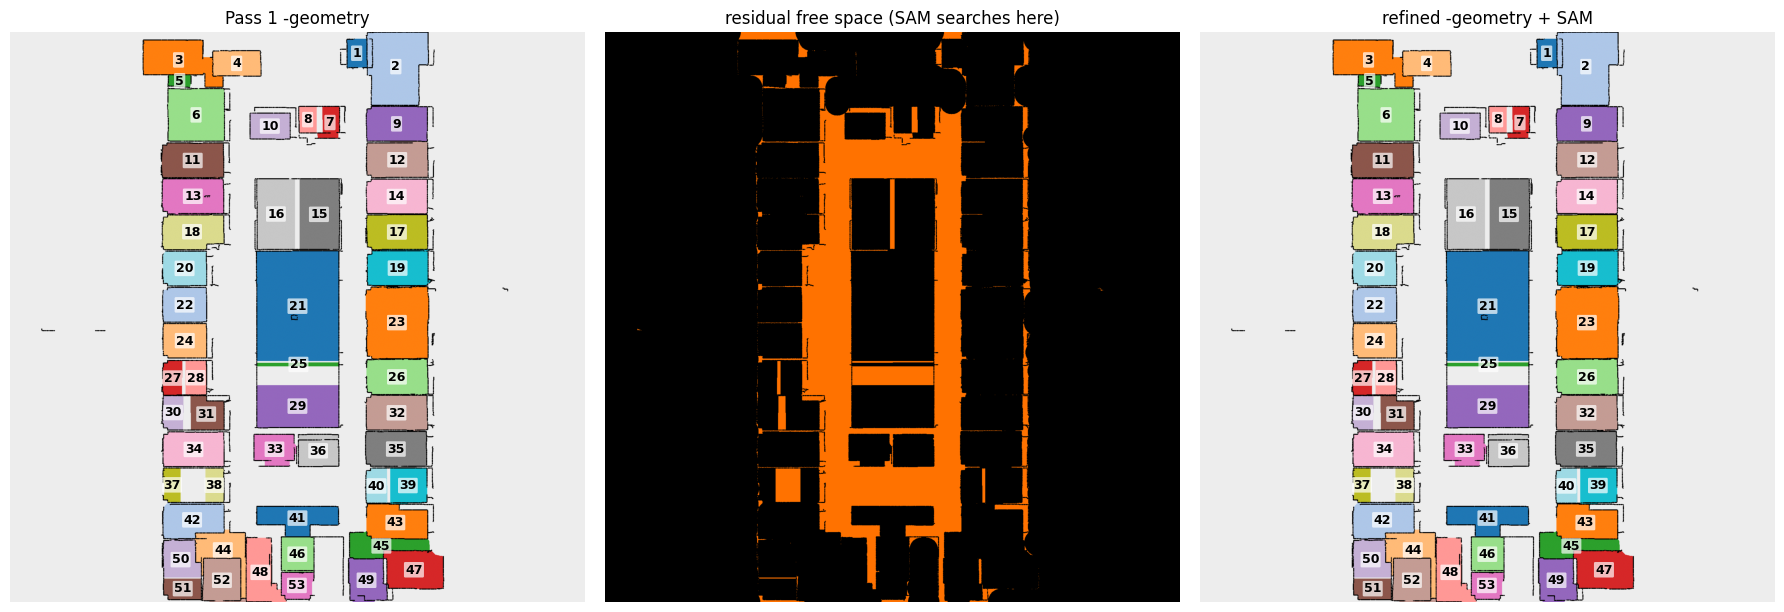

In [7]:
if SHOW_DEBUG:
    viz.show_sam_debug(dict(walls=walls, footprint=footprint), geom_labels, refined)

In [8]:
# ===== Save refined labels + package stage4_sam_refined back to (Drive) OUT_ROOT =====
out_dir = A.ensure_dir(A.stage_dir(OUT_ROOT, A.STAGE4))
A.save_npy(os.path.join(out_dir, A.REFINED_LABELS_NPY), refined.astype('int32'))
A.save_label_png(os.path.join(out_dir, A.REFINED_LABELS_PNG), refined)
A.save_transform(os.path.join(out_dir, A.TRANSFORM_JSON), tf)
A.save_config(os.path.join(out_dir, A.CONFIG_JSON), CFG)
zip_path = A.package_stage(OUT_ROOT, A.STAGE4)
print('packaged ->', zip_path)

packaged -> /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM/scan2bim_out/stage4_sam_refined.zip


## 5 - Next: produce SAM-refined wall clouds (Notebook 5)
After this notebook finishes, download `stage4_sam_refined.zip` from Google Drive, place it in
your local `scan2bim_out/`, then **run Notebook 5**
(`notebook_5_walls_on_sam_refined.ipynb`). It assigns walls on these SAM-refined masks and
writes `stage5_walls_sam_refined/`  - your watershed-based `stage3_walls/` is left untouched.
The cell below triggers the browser download when running in Colab.

In [9]:
try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print('Not in Colab - find the ZIP at:', zip_path)

Not in Colab - find the ZIP at: /Users/jacksonmatsumura/Documents/ONESTRUCTION-Point-Cloud-to-BIM/scan2bim_out/stage4_sam_refined.zip
